In [25]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import signal

In [26]:
PROJECT_ROOT = Path.cwd().parent
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR = OUTPUTS_DIR / "figures"
TABLES_DIR = OUTPUTS_DIR / "tables"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

print("PROCESSED_DIR:", PROCESSED_DIR)

PROCESSED_DIR: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/data/processed


In [27]:
EMOTIBIT_IDS = [f"EmotiBit_{i}" for i in range(1, 8)]
SEGMENTS = ["pre_meditation", "main_meditation", "recovery"]
CHANNELS = ["PPG_1", "PPG_2", "PPG_3"]

# Use main meditation most heavily for channel choice
SEGMENT_WEIGHTS = {
    "pre_meditation": 0.25,
    "main_meditation": 0.60,
    "recovery": 0.15,
}

# Your current visual picks to compare against
VISUAL_PICK_MAP = {
    "EmotiBit_1": "PPG_1",
    "EmotiBit_2": "PPG_1",
    "EmotiBit_3": "PPG_1",
    "EmotiBit_4": "PPG_2",
    "EmotiBit_5": "PPG_1",
    "EmotiBit_6": "PPG_2",
    "EmotiBit_7": "PPG_1",
}

# Plausible pulse band for PPG (Hz)
PULSE_BAND = (0.7, 3.0)

# Slightly broader "noise/reference" band for comparison
REFERENCE_BAND = (0.1, 8.0)

MIN_REQUIRED_SAMPLES = 100

In [28]:
def load_segment_csv(emotibit_id, segment):
    path = PROCESSED_DIR / f"{emotibit_id}_{segment}.csv"
    if not path.exists():
        return None, path
    return pd.read_csv(path), path


def estimate_fs_from_timestamps(timestamps):
    timestamps = np.asarray(timestamps, dtype=float)
    if len(timestamps) < 2:
        return np.nan
    diffs = np.diff(timestamps)
    diffs = diffs[np.isfinite(diffs)]
    diffs = diffs[diffs > 0]
    if len(diffs) == 0:
        return np.nan
    return 1.0 / np.median(diffs)


def robust_zscore(x):
    x = np.asarray(x, dtype=float)
    med = np.nanmedian(x)
    mad = np.nanmedian(np.abs(x - med))
    if mad == 0 or np.isnan(mad):
        return np.full_like(x, np.nan, dtype=float)
    return 0.6745 * (x - med) / mad


def nan_fraction(x):
    x = np.asarray(x, dtype=float)
    return float(np.mean(~np.isfinite(x)))


def robust_outlier_fraction(x, z_thresh=5.0):
    z = robust_zscore(x)
    if np.all(np.isnan(z)):
        return np.nan
    return float(np.nanmean(np.abs(z) > z_thresh))


def clipping_fraction(x):
    """
    Simple indicator: fraction equal to global min or max.
    Not perfect, but useful to catch repeated saturation at extremes.
    """
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return np.nan

    xmin = np.min(x)
    xmax = np.max(x)
    frac = np.mean((x == xmin) | (x == xmax))
    return float(frac)


def signal_variability_iqr(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return np.nan
    q75, q25 = np.percentile(x, [75, 25])
    return float(q75 - q25)


def derivative_noise_std(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) < 2:
        return np.nan
    dx = np.diff(x)
    return float(np.std(dx))


def detrend_for_sqi(x):
    x = np.asarray(x, dtype=float)
    x = x.copy()
    mask = np.isfinite(x)
    if np.sum(mask) < 3:
        return x
    x[~mask] = np.nanmedian(x[mask])
    return signal.detrend(x, type="linear")


def bandpower(freqs, psd, f_low, f_high):
    mask = (freqs >= f_low) & (freqs <= f_high)
    if not np.any(mask):
        return np.nan
    return float(np.trapz(psd[mask], freqs[mask]))


def pulse_band_power_ratio(x, fs, pulse_band=(0.7, 3.0), reference_band=(0.1, 8.0)):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) < 256 or not np.isfinite(fs):
        return np.nan

    x = detrend_for_sqi(x)
    nperseg = min(4096, len(x))
    freqs, psd = signal.welch(x, fs=fs, nperseg=nperseg)

    pulse_power = bandpower(freqs, psd, pulse_band[0], pulse_band[1])
    ref_power = bandpower(freqs, psd, reference_band[0], reference_band[1])

    if not np.isfinite(pulse_power) or not np.isfinite(ref_power) or ref_power <= 0:
        return np.nan

    return float(pulse_power / ref_power)


def autocorr_peak_strength(x, fs, min_bpm=40, max_bpm=120):
    """
    Look for strongest positive autocorrelation at plausible heart-rate lags.
    40 bpm -> 1.5 sec
    120 bpm -> 0.5 sec
    """
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) < 256 or not np.isfinite(fs):
        return np.nan

    x = detrend_for_sqi(x)
    x = x - np.mean(x)
    std = np.std(x)
    if std == 0 or np.isnan(std):
        return np.nan

    x = x / std
    ac = signal.correlate(x, x, mode="full")
    ac = ac[len(ac)//2:]  # non-negative lags only

    # normalize
    if ac[0] == 0:
        return np.nan
    ac = ac / ac[0]

    min_lag = int(np.floor(fs * 60.0 / max_bpm))  # 0.5 sec-ish
    max_lag = int(np.ceil(fs * 60.0 / min_bpm))   # 1.5 sec-ish

    if max_lag >= len(ac):
        max_lag = len(ac) - 1
    if min_lag >= max_lag:
        return np.nan

    peak = np.max(ac[min_lag:max_lag+1])
    return float(peak)


def compute_channel_sqi(x, timestamps):
    x = np.asarray(x, dtype=float)
    timestamps = np.asarray(timestamps, dtype=float)

    fs = estimate_fs_from_timestamps(timestamps)

    return {
        "fs_estimated": fs,
        "n_samples": int(len(x)),
        "nan_fraction": nan_fraction(x),
        "outlier_fraction": robust_outlier_fraction(x, z_thresh=5.0),
        "clipping_fraction": clipping_fraction(x),
        "iqr": signal_variability_iqr(x),
        "diff_std": derivative_noise_std(x),
        "pulse_band_ratio": pulse_band_power_ratio(x, fs, PULSE_BAND, REFERENCE_BAND),
        "autocorr_peak_strength": autocorr_peak_strength(x, fs, min_bpm=40, max_bpm=120),
    }

In [29]:
rows = []

for emotibit_id in EMOTIBIT_IDS:
    for segment in SEGMENTS:
        df, path = load_segment_csv(emotibit_id, segment)

        if df is None:
            print("Missing file:", path)
            continue

        timestamps = df["timestamp"].values.astype(float)

        for ch in CHANNELS:
            if ch not in df.columns:
                print(f"Missing channel {ch} in {path.name}")
                continue

            x = df[ch].values.astype(float)

            if len(x) < MIN_REQUIRED_SAMPLES:
                continue

            sqi = compute_channel_sqi(x, timestamps)

            rows.append({
                "emotibit_id": emotibit_id,
                "segment": segment,
                "channel": ch,
                **sqi
            })

sqi_df = pd.DataFrame(rows)
display(sqi_df.head(20))

/var/folders/qd/vssg284933g4s6zhb69zzfb80000gn/T/ipykernel_23553/2781010807.py:89: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(psd[mask], freqs[mask]))
/var/folders/qd/vssg284933g4s6zhb69zzfb80000gn/T/ipykernel_23553/2781010807.py:89: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(psd[mask], freqs[mask]))
/var/folders/qd/vssg284933g4s6zhb69zzfb80000gn/T/ipykernel_23553/2781010807.py:89: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(psd[mask], freqs[mask]))
/var/folders/qd/vssg284933g4s6zhb69zzfb80000gn/T/ipykernel_23553/2781010807.py:89: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions

,emotibit_id,segment,channel,fs_estimated,n_samples,nan_fraction,outlier_fraction,clipping_fraction,iqr,diff_std,pulse_band_ratio,autocorr_peak_strength
0,EmotiBit_1,pre_meditation,PPG_1,99.496057,24288,0.0,0.203310,0.000082,698.00,25.095682,0.318672,0.963172
1,EmotiBit_1,pre_meditation,PPG_2,99.496057,24288,0.0,0.000000,0.000082,180.00,23.539243,0.151686,0.962871
2,EmotiBit_1,pre_meditation,PPG_3,99.496057,24288,0.0,0.000000,0.000082,51.00,22.073411,0.475025,0.706074
3,EmotiBit_1,main_meditation,PPG_1,99.496057,74968,0.0,0.000000,0.000027,1193.00,25.265772,0.222108,0.964457
4,EmotiBit_1,main_meditation,PPG_2,99.496057,74968,0.0,0.000000,0.000027,289.00,23.673297,0.189272,0.961802
5,EmotiBit_1,main_meditation,PPG_3,99.496057,74968,0.0,0.004562,0.000027,36.00,22.342707,0.414111,0.727794
6,EmotiBit_1,recovery,PPG_1,99.496057,9430,0.0,0.117391,0.000318,96.00,25.333333,0.222233,0.947248
7,EmotiBit_1,recovery,PPG_2,99.496057,9430,0.0,0.102651,0.000212,134.00,23.527667,0.057625,0.950960
8,EmotiBit_1,recovery,PPG_3,99.496057,9430,0.0,0.057158,0.000212,27.00,22.472486,0.417542,0.826100
9,EmotiBit_2,pre_meditation,PPG_1,100.020871,24416,0.0,0.000000,0.000082,210.00,25.280215,0.425681,0.882597


In [30]:
out_path = TABLES_DIR / "ppg_channel_sqi_summary.csv"
sqi_df.to_csv(out_path, index=False)
print("Saved:", out_path)

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/tables/ppg_channel_sqi_summary.csv


In [31]:
main_sqi = sqi_df[sqi_df["segment"] == "main_meditation"].copy()

display(
    main_sqi.sort_values(["emotibit_id", "channel"])[[
        "emotibit_id", "channel", "nan_fraction", "outlier_fraction",
        "clipping_fraction", "iqr", "diff_std", "pulse_band_ratio", "autocorr_peak_strength"
    ]]
)

,emotibit_id,channel,nan_fraction,outlier_fraction,clipping_fraction,iqr,diff_std,pulse_band_ratio,autocorr_peak_strength
3,EmotiBit_1,PPG_1,0.0,0.000000,0.000027,1193.00,25.265772,0.222108,0.964457
4,EmotiBit_1,PPG_2,0.0,0.000000,0.000027,289.00,23.673297,0.189272,0.961802
5,EmotiBit_1,PPG_3,0.0,0.004562,0.000027,36.00,22.342707,0.414111,0.727794
12,EmotiBit_2,PPG_1,0.0,0.000000,0.000040,2203.75,26.213059,0.763065,0.950321
13,EmotiBit_2,PPG_2,0.0,0.000013,0.000027,427.00,463.698407,0.289051,0.009299
14,EmotiBit_2,PPG_3,0.0,0.000000,0.000027,61.00,23.034608,0.238212,0.241604
21,EmotiBit_3,PPG_1,0.0,0.000000,0.000027,3224.00,26.066077,0.446721,0.984257
22,EmotiBit_3,PPG_2,0.0,0.000027,0.000027,1889.75,679.003077,0.296932,0.324182
23,EmotiBit_3,PPG_3,0.0,0.000000,0.000027,168.00,21.522985,0.631078,0.717601
30,EmotiBit_4,PPG_1,0.0,0.000000,0.000027,448.00,28.850684,0.812723,0.950031


In [32]:
rank_df = sqi_df.copy()

# Lower is better
for col in ["nan_fraction", "outlier_fraction", "clipping_fraction", "diff_std"]:
    rank_df[f"{col}_rank"] = rank_df.groupby(["emotibit_id", "segment"])[col].rank(
        ascending=True, method="average"
    )

# Higher is better
for col in ["iqr", "pulse_band_ratio", "autocorr_peak_strength"]:
    rank_df[f"{col}_rank"] = rank_df.groupby(["emotibit_id", "segment"])[col].rank(
        ascending=False, method="average"
    )

rank_cols = [
    "nan_fraction_rank",
    "outlier_fraction_rank",
    "clipping_fraction_rank",
    "diff_std_rank",
    "iqr_rank",
    "pulse_band_ratio_rank",
    "autocorr_peak_strength_rank",
]

rank_df["segment_rank_score"] = rank_df[rank_cols].mean(axis=1)

display(rank_df.head(20))

,emotibit_id,segment,channel,fs_estimated,n_samples,nan_fraction,outlier_fraction,clipping_fraction,iqr,diff_std,pulse_band_ratio,autocorr_peak_strength,nan_fraction_rank,outlier_fraction_rank,clipping_fraction_rank,diff_std_rank,iqr_rank,pulse_band_ratio_rank,autocorr_peak_strength_rank,segment_rank_score
0,EmotiBit_1,pre_meditation,PPG_1,99.496057,24288,0.0,0.203310,0.000082,698.00,25.095682,0.318672,0.963172,2.0,3.0,2.0,3.0,1.0,2.0,1.0,2.000000
1,EmotiBit_1,pre_meditation,PPG_2,99.496057,24288,0.0,0.000000,0.000082,180.00,23.539243,0.151686,0.962871,2.0,1.5,2.0,2.0,2.0,3.0,2.0,2.071429
2,EmotiBit_1,pre_meditation,PPG_3,99.496057,24288,0.0,0.000000,0.000082,51.00,22.073411,0.475025,0.706074,2.0,1.5,2.0,1.0,3.0,1.0,3.0,1.928571
3,EmotiBit_1,main_meditation,PPG_1,99.496057,74968,0.0,0.000000,0.000027,1193.00,25.265772,0.222108,0.964457,2.0,1.5,2.0,3.0,1.0,2.0,1.0,1.785714
4,EmotiBit_1,main_meditation,PPG_2,99.496057,74968,0.0,0.000000,0.000027,289.00,23.673297,0.189272,0.961802,2.0,1.5,2.0,2.0,2.0,3.0,2.0,2.071429
5,EmotiBit_1,main_meditation,PPG_3,99.496057,74968,0.0,0.004562,0.000027,36.00,22.342707,0.414111,0.727794,2.0,3.0,2.0,1.0,3.0,1.0,3.0,2.142857
6,EmotiBit_1,recovery,PPG_1,99.496057,9430,0.0,0.117391,0.000318,96.00,25.333333,0.222233,0.947248,2.0,3.0,3.0,3.0,2.0,2.0,2.0,2.428571
7,EmotiBit_1,recovery,PPG_2,99.496057,9430,0.0,0.102651,0.000212,134.00,23.527667,0.057625,0.950960,2.0,2.0,1.5,2.0,1.0,3.0,1.0,1.785714
8,EmotiBit_1,recovery,PPG_3,99.496057,9430,0.0,0.057158,0.000212,27.00,22.472486,0.417542,0.826100,2.0,1.0,1.5,1.0,3.0,1.0,3.0,1.785714
9,EmotiBit_2,pre_meditation,PPG_1,100.020871,24416,0.0,0.000000,0.000082,210.00,25.280215,0.425681,0.882597,2.0,2.0,2.0,3.0,1.0,1.0,1.0,1.714286


In [33]:
out_path = TABLES_DIR / "ppg_channel_segment_rankings.csv"
rank_df.to_csv(out_path, index=False)
print("Saved:", out_path)

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/tables/ppg_channel_segment_rankings.csv


In [34]:
weighted_rows = []

for emotibit_id in EMOTIBIT_IDS:
    sub = rank_df[rank_df["emotibit_id"] == emotibit_id].copy()

    for ch in CHANNELS:
        sub_ch = sub[sub["channel"] == ch].copy()
        if len(sub_ch) == 0:
            continue

        score = 0.0
        weight_sum = 0.0

        for _, row in sub_ch.iterrows():
            w = SEGMENT_WEIGHTS.get(row["segment"], 0.0)
            score += w * row["segment_rank_score"]
            weight_sum += w

        weighted_score = score / weight_sum if weight_sum > 0 else np.nan

        weighted_rows.append({
            "emotibit_id": emotibit_id,
            "channel": ch,
            "weighted_rank_score": weighted_score,
        })

weighted_scores_df = pd.DataFrame(weighted_rows)

display(weighted_scores_df.sort_values(["emotibit_id", "weighted_rank_score"]))

,emotibit_id,channel,weighted_rank_score
0,EmotiBit_1,PPG_1,1.935714
1,EmotiBit_1,PPG_2,2.028571
2,EmotiBit_1,PPG_3,2.035714
3,EmotiBit_2,PPG_1,1.660714
5,EmotiBit_2,PPG_3,2.100000
4,EmotiBit_2,PPG_2,2.239286
8,EmotiBit_3,PPG_3,1.717857
6,EmotiBit_3,PPG_1,1.746429
7,EmotiBit_3,PPG_2,2.535714
9,EmotiBit_4,PPG_1,1.821429


In [35]:
final_rankings = (
    weighted_scores_df
    .sort_values(["emotibit_id", "weighted_rank_score", "channel"])
    .groupby("emotibit_id", as_index=False)
    .apply(lambda g: g.sort_values(["weighted_rank_score", "channel"]).reset_index(drop=True))
    .reset_index(drop=True)
)

# Build compact best/backup table
best_rows = []
for emotibit_id in EMOTIBIT_IDS:
    g = weighted_scores_df[weighted_scores_df["emotibit_id"] == emotibit_id].sort_values(
        ["weighted_rank_score", "channel"]
    ).reset_index(drop=True)

    if len(g) == 0:
        continue

    best_channel = g.loc[0, "channel"]
    best_score = g.loc[0, "weighted_rank_score"]
    backup_channel = g.loc[1, "channel"] if len(g) > 1 else None
    backup_score = g.loc[1, "weighted_rank_score"] if len(g) > 1 else np.nan
    gap = backup_score - best_score if np.isfinite(backup_score) and np.isfinite(best_score) else np.nan

    if pd.isna(gap):
        confidence = "unknown"
    elif gap >= 0.75:
        confidence = "high"
    elif gap >= 0.35:
        confidence = "medium"
    else:
        confidence = "low"

    best_rows.append({
        "emotibit_id": emotibit_id,
        "sqi_best_channel": best_channel,
        "sqi_best_score": best_score,
        "sqi_backup_channel": backup_channel,
        "sqi_backup_score": backup_score,
        "score_gap": gap,
        "sqi_confidence": confidence,
        "visual_pick_channel": VISUAL_PICK_MAP.get(emotibit_id),
        "matches_visual_pick": best_channel == VISUAL_PICK_MAP.get(emotibit_id),
    })

best_channel_df = pd.DataFrame(best_rows).sort_values("emotibit_id").reset_index(drop=True)
display(best_channel_df)

/var/folders/qd/vssg284933g4s6zhb69zzfb80000gn/T/ipykernel_23553/3372974058.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sort_values(["weighted_rank_score", "channel"]).reset_index(drop=True))


,emotibit_id,sqi_best_channel,sqi_best_score,sqi_backup_channel,sqi_backup_score,score_gap,sqi_confidence,visual_pick_channel,matches_visual_pick
0,EmotiBit_1,PPG_1,1.935714,PPG_2,2.028571,0.092857,low,PPG_1,True
1,EmotiBit_2,PPG_1,1.660714,PPG_3,2.100000,0.439286,medium,PPG_1,True
2,EmotiBit_3,PPG_3,1.717857,PPG_1,1.746429,0.028571,low,PPG_1,False
3,EmotiBit_4,PPG_1,1.821429,PPG_3,2.035714,0.214286,low,PPG_2,False
4,EmotiBit_5,PPG_1,1.753571,PPG_2,1.839286,0.085714,low,PPG_1,True
5,EmotiBit_6,PPG_3,1.900000,PPG_2,1.992857,0.092857,low,PPG_2,False
6,EmotiBit_7,PPG_1,1.575000,PPG_2,2.210714,0.635714,medium,PPG_1,True


In [36]:
out_path = TABLES_DIR / "ppg_channel_rankings.csv"
best_channel_df.to_csv(out_path, index=False)
print("Saved:", out_path)

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/tables/ppg_channel_rankings.csv


In [37]:
final_rows = []

for _, row in best_channel_df.iterrows():
    emotibit_id = row["emotibit_id"]
    sqi_best = row["sqi_best_channel"]
    sqi_backup = row["sqi_backup_channel"]
    visual_pick = row["visual_pick_channel"]
    confidence = row["sqi_confidence"]
    matches = bool(row["matches_visual_pick"])

    if matches:
        final_channel = visual_pick
        backup_channel = sqi_backup if sqi_backup != final_channel else None
        decision_reason = "SQI agrees with visual pick"
    else:
        if confidence == "high":
            final_channel = sqi_best
            backup_channel = visual_pick
            decision_reason = "SQI strongly challenges visual pick"
        else:
            final_channel = visual_pick
            backup_channel = sqi_best
            decision_reason = "Keep visual pick; SQI disagreement not strong enough"

    final_rows.append({
        "emotibit_id": emotibit_id,
        "final_selected_channel": final_channel,
        "backup_channel": backup_channel,
        "visual_pick_channel": visual_pick,
        "sqi_best_channel": sqi_best,
        "sqi_confidence": confidence,
        "matches_visual_pick": matches,
        "decision_reason": decision_reason,
    })

final_channel_map_df = pd.DataFrame(final_rows).sort_values("emotibit_id").reset_index(drop=True)
display(final_channel_map_df)

,emotibit_id,final_selected_channel,backup_channel,visual_pick_channel,sqi_best_channel,sqi_confidence,matches_visual_pick,decision_reason
0,EmotiBit_1,PPG_1,PPG_2,PPG_1,PPG_1,low,True,SQI agrees with visual pick
1,EmotiBit_2,PPG_1,PPG_3,PPG_1,PPG_1,medium,True,SQI agrees with visual pick
2,EmotiBit_3,PPG_1,PPG_3,PPG_1,PPG_3,low,False,Keep visual pick; SQI disagreement not strong ...
3,EmotiBit_4,PPG_2,PPG_1,PPG_2,PPG_1,low,False,Keep visual pick; SQI disagreement not strong ...
4,EmotiBit_5,PPG_1,PPG_2,PPG_1,PPG_1,low,True,SQI agrees with visual pick
5,EmotiBit_6,PPG_2,PPG_3,PPG_2,PPG_3,low,False,Keep visual pick; SQI disagreement not strong ...
6,EmotiBit_7,PPG_1,PPG_2,PPG_1,PPG_1,medium,True,SQI agrees with visual pick


In [38]:
out_path = TABLES_DIR / "final_validated_channel_map.csv"
final_channel_map_df.to_csv(out_path, index=False)
print("Saved:", out_path)

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/tables/final_validated_channel_map.csv


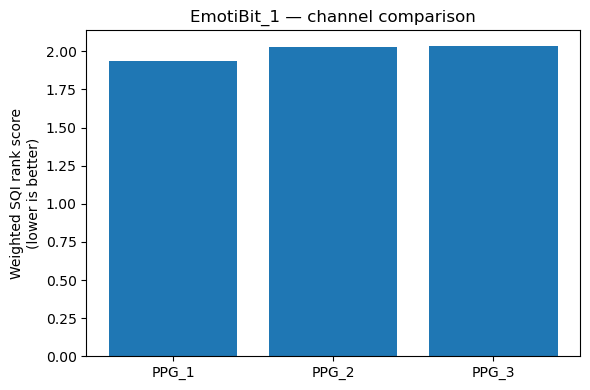

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/EmotiBit_1_weighted_sqi_scores.png


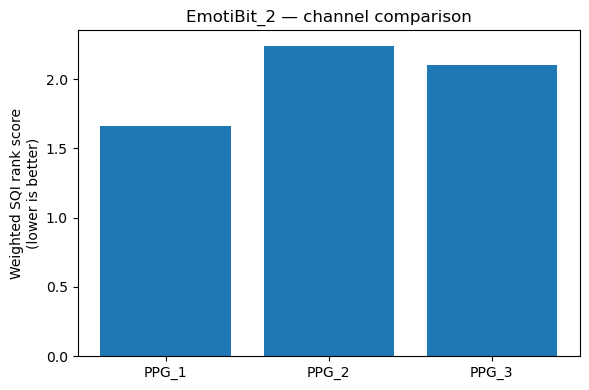

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/EmotiBit_2_weighted_sqi_scores.png


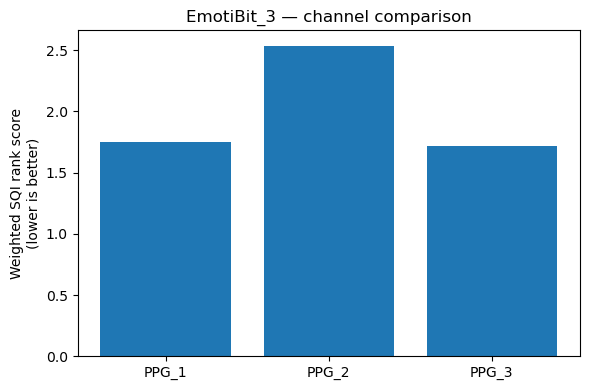

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/EmotiBit_3_weighted_sqi_scores.png


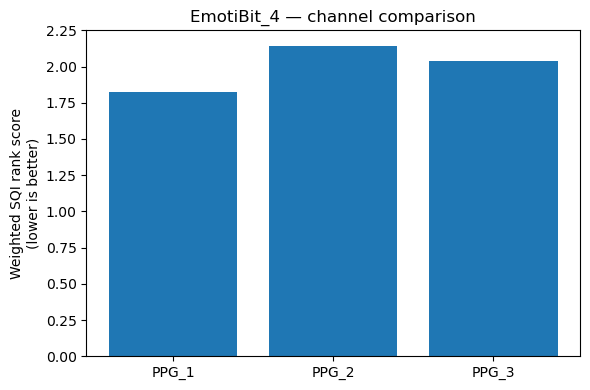

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/EmotiBit_4_weighted_sqi_scores.png


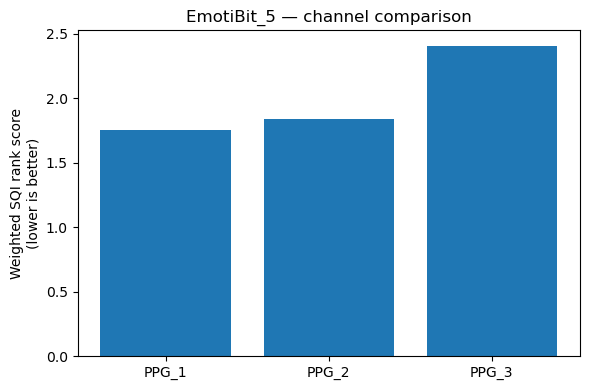

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/EmotiBit_5_weighted_sqi_scores.png


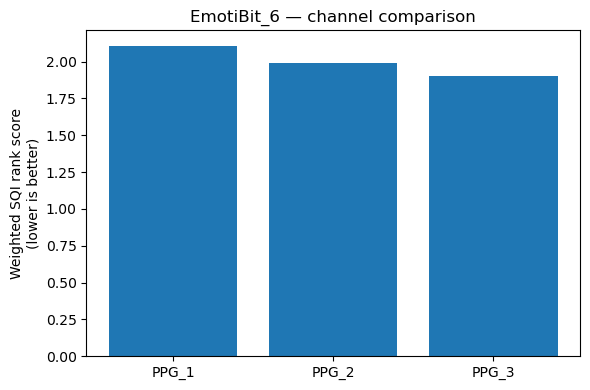

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/EmotiBit_6_weighted_sqi_scores.png


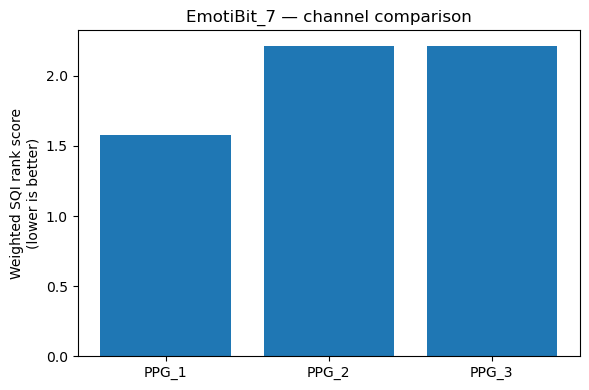

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/EmotiBit_7_weighted_sqi_scores.png


In [39]:
for emotibit_id in EMOTIBIT_IDS:
    g = weighted_scores_df[weighted_scores_df["emotibit_id"] == emotibit_id].sort_values("channel")

    plt.figure(figsize=(6, 4))
    plt.bar(g["channel"], g["weighted_rank_score"])
    plt.ylabel("Weighted SQI rank score\n(lower is better)")
    plt.title(f"{emotibit_id} — channel comparison")
    plt.tight_layout()

    out_path = FIGURES_DIR / f"{emotibit_id}_weighted_sqi_scores.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()

    print("Saved:", out_path)

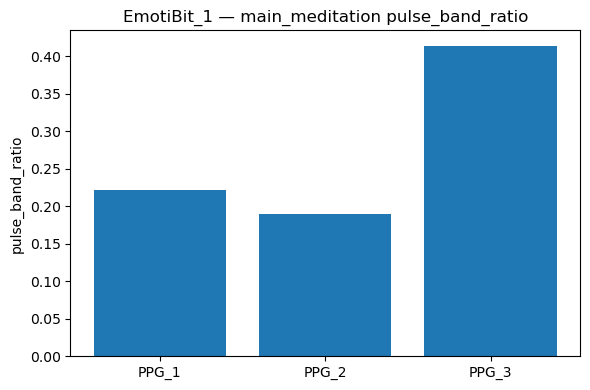

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/EmotiBit_1_main_pulse_band_ratio.png


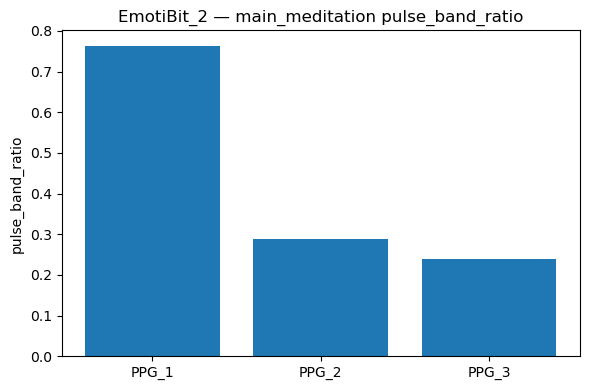

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/EmotiBit_2_main_pulse_band_ratio.png


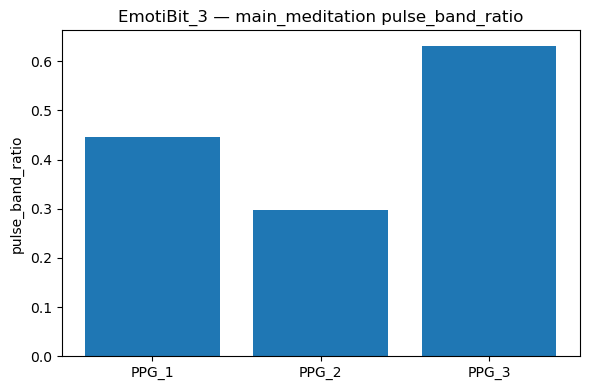

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/EmotiBit_3_main_pulse_band_ratio.png


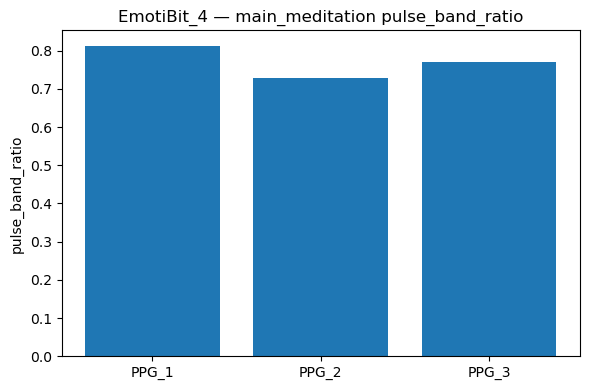

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/EmotiBit_4_main_pulse_band_ratio.png


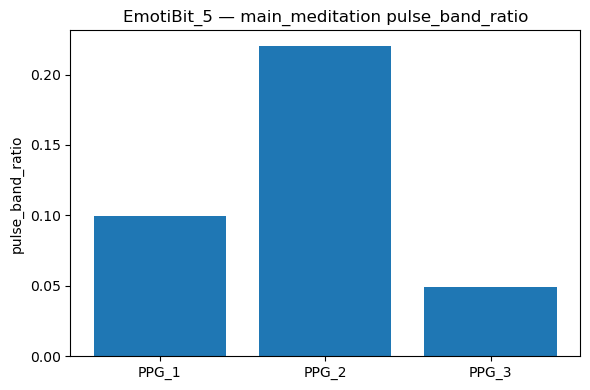

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/EmotiBit_5_main_pulse_band_ratio.png


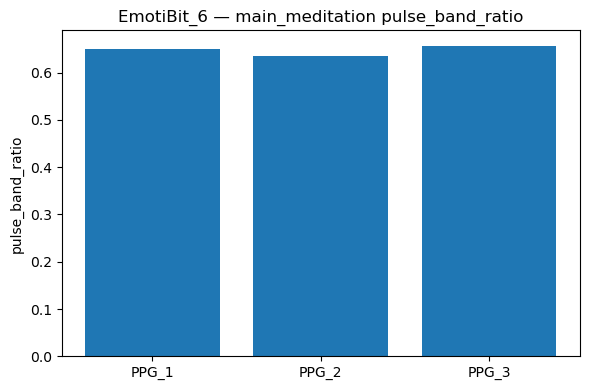

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/EmotiBit_6_main_pulse_band_ratio.png


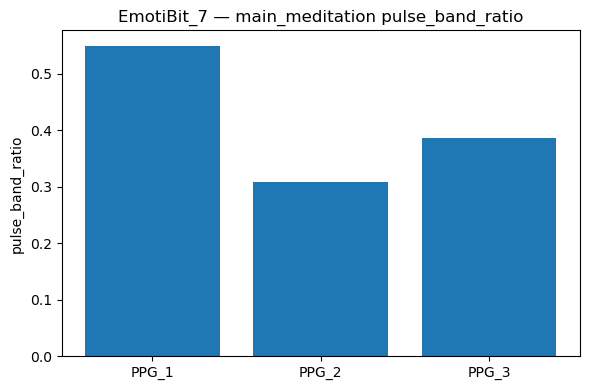

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/EmotiBit_7_main_pulse_band_ratio.png


In [40]:
metric = "pulse_band_ratio"

for emotibit_id in EMOTIBIT_IDS:
    g = main_sqi[main_sqi["emotibit_id"] == emotibit_id].sort_values("channel")

    plt.figure(figsize=(6, 4))
    plt.bar(g["channel"], g[metric])
    plt.ylabel(metric)
    plt.title(f"{emotibit_id} — main_meditation {metric}")
    plt.tight_layout()

    out_path = FIGURES_DIR / f"{emotibit_id}_main_{metric}.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()

    print("Saved:", out_path)

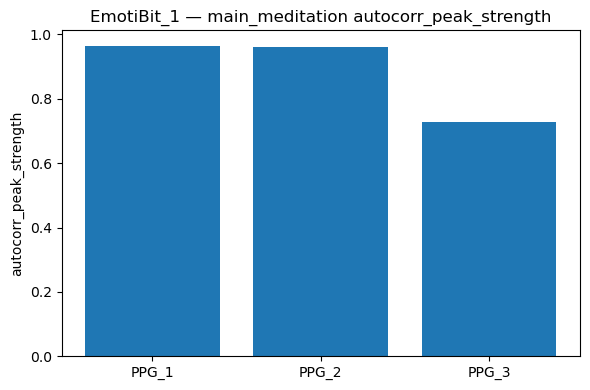

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/EmotiBit_1_main_autocorr_peak_strength.png


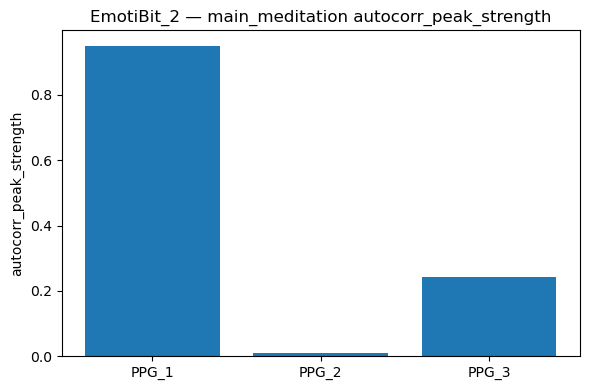

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/EmotiBit_2_main_autocorr_peak_strength.png


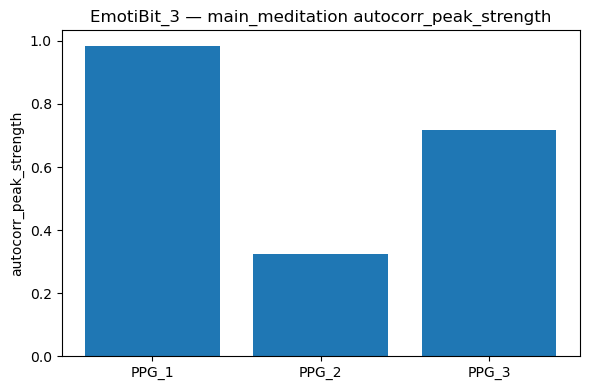

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/EmotiBit_3_main_autocorr_peak_strength.png


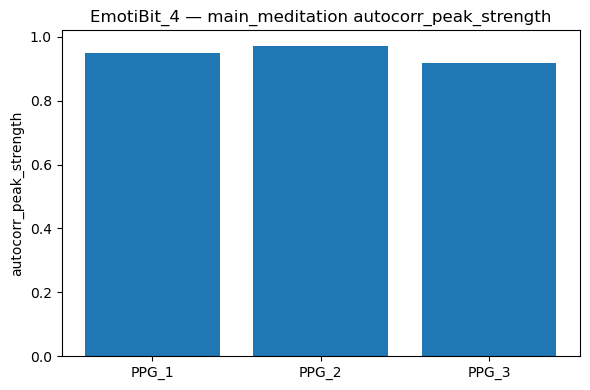

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/EmotiBit_4_main_autocorr_peak_strength.png


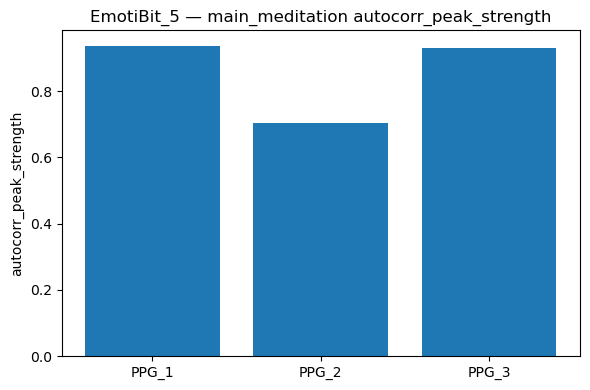

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/EmotiBit_5_main_autocorr_peak_strength.png


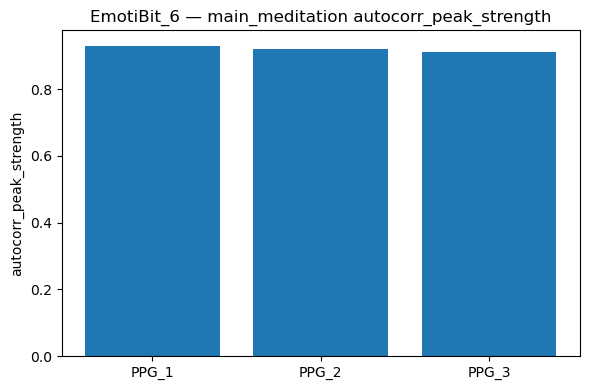

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/EmotiBit_6_main_autocorr_peak_strength.png


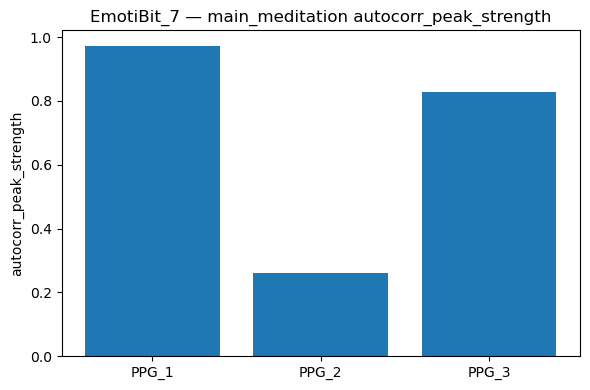

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/EmotiBit_7_main_autocorr_peak_strength.png


In [41]:
metric = "autocorr_peak_strength"

for emotibit_id in EMOTIBIT_IDS:
    g = main_sqi[main_sqi["emotibit_id"] == emotibit_id].sort_values("channel")

    plt.figure(figsize=(6, 4))
    plt.bar(g["channel"], g[metric])
    plt.ylabel(metric)
    plt.title(f"{emotibit_id} — main_meditation {metric}")
    plt.tight_layout()

    out_path = FIGURES_DIR / f"{emotibit_id}_main_{metric}.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()

    print("Saved:", out_path)

In [42]:
print("=== SQI VALIDATION SUMMARY ===")
print("Generated files:")
print("- ppg_channel_sqi_summary.csv")
print("- ppg_channel_segment_rankings.csv")
print("- ppg_channel_rankings.csv")
print("- final_validated_channel_map.csv")
print()
print("Use final_validated_channel_map.csv for the next preprocessing notebook.")

=== SQI VALIDATION SUMMARY ===
Generated files:
- ppg_channel_sqi_summary.csv
- ppg_channel_segment_rankings.csv
- ppg_channel_rankings.csv
- final_validated_channel_map.csv

Use final_validated_channel_map.csv for the next preprocessing notebook.
